In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ziadadelkhalifa","key":"39e7c887822067846ce1161b7bc15534"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
#Downloading the data from kaggle

!kaggle datasets download -d abedkhooli/arabic-100k-reviews

Dataset URL: https://www.kaggle.com/datasets/abedkhooli/arabic-100k-reviews
License(s): copyright-authors
 29% 5.00M/17.0M [00:00<00:00, 30.1MB/s]
100% 17.0M/17.0M [00:00<00:00, 74.7MB/s]


In [5]:
!unzip /content/arabic-100k-reviews.zip -d arabic_reviwes

Archive:  /content/arabic-100k-reviews.zip
  inflating: arabic_reviwes/ar_reviews_100k.tsv  


In [3]:
file_path = '/content/arabic_reviwes/ar_reviews_100k.tsv'

In [4]:
model_name = 'google-bert/bert-base-uncased'

In [5]:
from transformers import BertTokenizer, TFBertForSequenceClassification

tokenizer = BertTokenizer.from_pretrained(model_name)

model = TFBertForSequenceClassification.from_pretrained(model_name)

Downloading:   0%|          | 0.00/226k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/570 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/511M [00:00<?, ?B/s]

In [6]:
import pandas as pd

df = pd.read_csv(file_path, sep='\t')

df

,label,text
0,Positive,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1,Positive,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2,Positive,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3,Positive,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4,Positive,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...
...,...,...
99994,Negative,معرفش ليه كنت عاوزة أكملها وهي مش عاجباني من ا...
99995,Negative,لا يستحق ان يكون في بوكنق لانه سيئ . لا شي. لا...
99996,Negative,كتاب ضعيف جدا ولم استمتع به. فى كل قصه سرد لحا...
99997,Negative,مملة جدا. محمد حسن علوان فنان بالكلمات، والوصف...


In [7]:
random_5_row = df.sample(n=5, random_state=42)

random_5_row

,label,text
26002,Positive,أقم على الماشي . بصورة عامة الغرفة جيدة وكل شي...
80420,Negative,لم تعجبني كباقي السلسلة و غير متحمس لقراءة الج...
19864,Positive,كان المكان ممتاز والأمن والاستقبال اوكي . . ال...
81525,Negative,القصة اجمالا مشوقة كونها تعتمد علي شخصيات يجمع...
57878,Mixed,اربع نجوم لولا الملل الذي اصابني في النهاية......


In [8]:
import numpy as np

sentiment_mapping = {
    0: 'mixed',
    1: 'negative',
    2: 'positive',
}

random_5_row = random_5_row.copy()

predicted_sentiments = []

for title in random_5_row['text']:

    inputs = tokenizer(title,)

    input_ids = inputs['input_ids']

    predictions = model.predict([input_ids])

    logits = predictions.logits

    predicted_class = np.argmax(logits)
    print("predicted id: ", predicted_class)

    print(predictions)

    predicted_sentiment = sentiment_mapping[predicted_class]
    predicted_sentiments.append(predicted_sentiment)

random_5_row['predicted_sentiment'] = predicted_sentiments

random_5_row

1/1 [==============================] - 7s 7s/step
predicted id:  1
TFSequenceClassifierOutput(loss=None, logits=array([[-0.4054705 ,  0.25557363]], dtype=float32), hidden_states=None, attentions=None)
1/1 [==============================] - 3s 3s/step
predicted id:  1
TFSequenceClassifierOutput(loss=None, logits=array([[-0.32279873,  0.22397462]], dtype=float32), hidden_states=None, attentions=None)
1/1 [==============================] - 0s 73ms/step
predicted id:  1
TFSequenceClassifierOutput(loss=None, logits=array([[-0.3189457 ,  0.19585705]], dtype=float32), hidden_states=None, attentions=None)
1/1 [==============================] - 0s 102ms/step
predicted id:  1
TFSequenceClassifierOutput(loss=None, logits=array([[-0.34354168,  0.23750639]], dtype=float32), hidden_states=None, attentions=None)
1/1 [==============================] - 0s 78ms/step
predicted id:  1
TFSequenceClassifierOutput(loss=None, logits=array([[-0.36853272,  0.27749482]], dtype=float32), hidden_states=None, atten

,label,text,predicted_sentiment
26002,Positive,أقم على الماشي . بصورة عامة الغرفة جيدة وكل شي...,negative
80420,Negative,لم تعجبني كباقي السلسلة و غير متحمس لقراءة الج...,negative
19864,Positive,كان المكان ممتاز والأمن والاستقبال اوكي . . ال...,negative
81525,Negative,القصة اجمالا مشوقة كونها تعتمد علي شخصيات يجمع...,negative
57878,Mixed,اربع نجوم لولا الملل الذي اصابني في النهاية......,negative


In [9]:
df.shape

(99999, 2)

In [10]:
df = df.sample(n=30000, random_state=42)

In [11]:
df.shape

(30000, 2)

<Axes: ylabel='Frequency'>

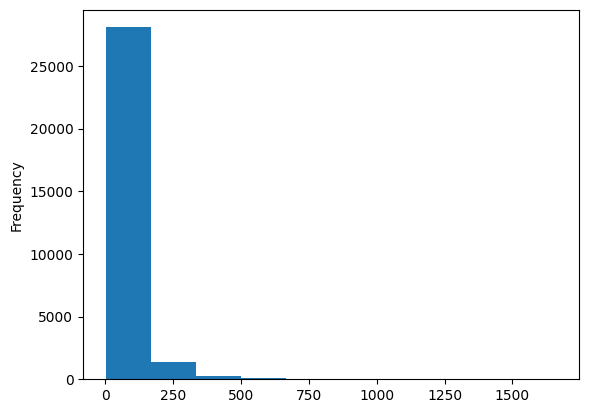

In [12]:
#to know the average length of a sentence
df.text.apply(lambda x: len(x.split())).plot(kind='hist')

In [13]:
import numpy as np

for l in np.unique(df['label']):
  print(l)

Mixed
Negative
Positive


In [14]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()
df['label'] = LE.fit_transform(df['label'])
df.head()

,label,text
26002,2,أقم على الماشي . بصورة عامة الغرفة جيدة وكل شي...
80420,1,لم تعجبني كباقي السلسلة و غير متحمس لقراءة الج...
19864,2,كان المكان ممتاز والأمن والاستقبال اوكي . . ال...
81525,1,القصة اجمالا مشوقة كونها تعتمد علي شخصيات يجمع...
57878,0,اربع نجوم لولا الملل الذي اصابني في النهاية......


In [15]:
for l in np.unique(df['label']):
  print(l)

0
1
2


In [16]:
from sklearn.model_selection import train_test_split
train, val = train_test_split(df, test_size=0.2, random_state=42)
train.head()

,label,text
26667,2,استمتعت . الموقع الخصوصيه. عدم توفر الانترنت
66268,0,مكان الفندق رائع قريب من المسجد النبوي . قرب م...
88175,1,لن اكرر الاقامة . . رائحة الشراشف سيئة لايوضع ...
34168,0,بسيط وممتع الى حد ما
35914,0,مرضي. القرب من الحرم. الاثاث لا يرتقي لفندق خم...


In [17]:
train.reset_index(drop=True, inplace=True)
train.head()

,label,text
0,2,استمتعت . الموقع الخصوصيه. عدم توفر الانترنت
1,0,مكان الفندق رائع قريب من المسجد النبوي . قرب م...
2,1,لن اكرر الاقامة . . رائحة الشراشف سيئة لايوضع ...
3,0,بسيط وممتع الى حد ما
4,0,مرضي. القرب من الحرم. الاثاث لا يرتقي لفندق خم...


In [18]:
val.reset_index(drop=True, inplace=True)
val.head(5)

,label,text
0,0,يحتاج للتطوير . تسجيل الخروج المتأخر. دخول تنظ...
1,1,المجهود المبالغ فيه فى اختيار و رسم التعابير و...
2,1,اخيس كتاب القصه مقتبسه
3,2,استثنائي. النظافه الطاغية في المكان والرقي في ...
4,1,لا انصح بالسكن فيه حتى يجدد . الموقع جيد ولكن ...


In [19]:
print("Training Set Shape :", train.shape)
print("Validation Set Shape :", val.shape)

Training Set Shape : (24000, 2)
Validation Set Shape : (6000, 2)


In [20]:
x_train = train['text'].to_numpy()
y_train = train['label'].to_numpy()
x_test = val['text'].to_numpy()
y_test = val['label'].to_numpy()

In [21]:
y_train

array([2, 0, 1, ..., 1, 2, 0])

In [22]:
y_test

array([0, 1, 1, ..., 0, 2, 2])

In [27]:
pip install ktrain==0.32.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.3/25.3 MB 10.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 56.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 653.6/653.6 kB 34.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 468.8/468.8 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 54.6 

In [28]:
pip install tensorflow==2.15.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 6.3 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.16.0
    Uninstalling wrapt-1.16.0:
      Successfully uninstalled wrapt-1.16.0
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: keras
    Found existing installation: keras 3.4.1
    Uninstalling keras-3.4.1:
      Successfully uninstalled keras-3.4.1
  Attempting uninstall: tensorboard
    Found existing installation

In [23]:
import ktrain
from ktrain import text
MODEL_NAME = 'bert-base-uncased'
categories = ['Mixed','Negative','Positive']
t = text.Transformer(MODEL_NAME, maxlen=200, class_names= categories)
trn = t.preprocess_train(x_train, y_train)#convert text data to numerical data
val = t.preprocess_test(x_test, y_test)

model = t.get_classifier()
learner = ktrain.get_learner(model, train_data=trn, val_data=val, batch_size=16)

preprocessing train...
language: ar
train sequence lengths:
	mean : 55
	95percentile : 198
	99percentile : 439


Downloading:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/226k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/455k [00:00<?, ?B/s]

Is Multi-Label? False
preprocessing test...
language: ar
test sequence lengths:
	mean : 55
	95percentile : 195
	99percentile : 445


Downloading:   0%|          | 0.00/511M [00:00<?, ?B/s]

In [26]:
import time
start = time.time()
learner.fit_onecycle(2e-5, 4)
stop = time.time()
print(f"Training time: {stop - start}s")



begin training using onecycle policy with max lr of 2e-05...
Epoch 1/4
1500/1500 [==============================] - 1090s 722ms/step - loss: 0.9404 - accuracy: 0.5075 - val_loss: 0.8251 - val_accuracy: 0.5940
Epoch 2/4
1500/1500 [==============================] - 1079s 719ms/step - loss: 0.7997 - accuracy: 0.6017 - val_loss: 0.7603 - val_accuracy: 0.6250
Epoch 3/4
1500/1500 [==============================] - 1079s 719ms/step - loss: 0.7432 - accuracy: 0.6413 - val_loss: 0.7403 - val_accuracy: 0.6432
Epoch 4/4
1500/1500 [==============================] - 1077s 718ms/step - loss: 0.6679 - accuracy: 0.6892 - val_loss: 0.7437 - val_accuracy: 0.6505
Training time: 4342.000325918198s


In [27]:
learner.validate(class_names= categories)

188/188 [==============================] - 85s 438ms/step
              precision    recall  f1-score   support

       Mixed       0.58      0.55      0.56      1991
    Negative       0.66      0.74      0.69      2067
    Positive       0.71      0.67      0.69      1942

    accuracy                           0.65      6000
   macro avg       0.65      0.65      0.65      6000
weighted avg       0.65      0.65      0.65      6000



array([[1086,  530,  375],
       [ 392, 1521,  154],
       [ 381,  265, 1296]])

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [28]:
predictor = ktrain.get_predictor(learner.model, preproc=t).save('/content/drive/MyDrive/finetune_BERT')

In [30]:
predictor = ktrain.load_predictor('/content/drive/MyDrive/finetune_BERT')
model = ktrain.get_predictor(predictor.model, predictor.preproc)

x = ["كله رائع بجد ربنا يكرمك", "اتقوا الله فينا بكفي رفع اسعار الرواتب بالحضيض"]
predictions = model.predict(x)

print(predictions)

1/1 [==============================] - 4s 4s/step
['Positive', 'Mixed']


In [31]:
import numpy as np

random_5_row = random_5_row.copy()

predicted_sentiments = []

for title in random_5_row['text']:

    predictions = model.predict(title)

    print(predictions)

    predicted_sentiments.append(predictions)

random_5_row['predicted_sentiment'] = predicted_sentiments

random_5_row

1/1 [==============================] - 0s 114ms/step
Mixed
1/1 [==============================] - 0s 118ms/step
Negative
1/1 [==============================] - 0s 124ms/step
Positive
1/1 [==============================] - 0s 124ms/step
Negative
1/1 [==============================] - 0s 114ms/step
Mixed


,label,text,predicted_sentiment
26002,Positive,أقم على الماشي . بصورة عامة الغرفة جيدة وكل شي...,Mixed
80420,Negative,لم تعجبني كباقي السلسلة و غير متحمس لقراءة الج...,Negative
19864,Positive,كان المكان ممتاز والأمن والاستقبال اوكي . . ال...,Positive
81525,Negative,القصة اجمالا مشوقة كونها تعتمد علي شخصيات يجمع...,Negative
57878,Mixed,اربع نجوم لولا الملل الذي اصابني في النهاية......,Mixed
